In [1227]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

In [1228]:
data = pd.read_csv("Bengaluru_House_Data.csv")
data.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [1229]:
data.shape

(13320, 9)

In [1230]:
data.groupby('area_type')['area_type'].agg('count')

area_type
Built-up  Area          2418
Carpet  Area              87
Plot  Area              2025
Super built-up  Area    8790
Name: area_type, dtype: int64

In [1231]:
data = data.drop(columns=['balcony', "society","area_type","availability"], axis=1)

In [1232]:
data.head()

,location,size,total_sqft,bath,price
0,Electronic City Phase II,2 BHK,1056,2.0,39.07
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00
2,Uttarahalli,3 BHK,1440,2.0,62.00
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00
4,Kothanur,2 BHK,1200,2.0,51.00


In [1233]:
data.isnull().sum()

location       1
size          16
total_sqft     0
bath          73
price          0
dtype: int64

In [1234]:
data2 = data.dropna()

In [1235]:
data2.isnull().sum()

location      0
size          0
total_sqft    0
bath          0
price         0
dtype: int64

In [1236]:
data2.head()

,location,size,total_sqft,bath,price
0,Electronic City Phase II,2 BHK,1056,2.0,39.07
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00
2,Uttarahalli,3 BHK,1440,2.0,62.00
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00
4,Kothanur,2 BHK,1200,2.0,51.00


In [1237]:
data2['size'].unique()

array(['2 BHK', '4 Bedroom', '3 BHK', '4 BHK', '6 Bedroom', '3 Bedroom',
       '1 BHK', '1 RK', '1 Bedroom', '8 Bedroom', '2 Bedroom',
       '7 Bedroom', '5 BHK', '7 BHK', '6 BHK', '5 Bedroom', '11 BHK',
       '9 BHK', '9 Bedroom', '27 BHK', '10 Bedroom', '11 Bedroom',
       '10 BHK', '19 BHK', '16 BHK', '43 Bedroom', '14 BHK', '8 BHK',
       '12 Bedroom', '13 BHK', '18 Bedroom'], dtype=object)

In [1238]:
data2['new_size'] = data2['size'].apply(lambda x: int(x.split(" ")[0]))

C:\Users\007\AppData\Local\Temp\ipykernel_14072\1745129744.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data2['new_size'] = data2['size'].apply(lambda x: int(x.split(" ")[0]))


In [1239]:
data2.head()

,location,size,total_sqft,bath,price,new_size
0,Electronic City Phase II,2 BHK,1056,2.0,39.07,2
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00,4
2,Uttarahalli,3 BHK,1440,2.0,62.00,3
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00,3
4,Kothanur,2 BHK,1200,2.0,51.00,2


In [1240]:
data2[data2['new_size']>20]

,location,size,total_sqft,bath,price,new_size
1718,2Electronic City Phase II,27 BHK,8000,27.0,230.0,27
4684,Munnekollal,43 Bedroom,2400,40.0,660.0,43


In [1241]:
data2['total_sqft'].unique()

array(['1056', '2600', '1440', ..., '1133 - 1384', '774', '4689'],
      dtype=object)

In [1242]:
def is_float(x):
    try: 
        float(x)
    except:
        return False
    return True

In [1243]:
data2[~data2['total_sqft'].apply(is_float)].head(10)

,location,size,total_sqft,bath,price,new_size
30,Yelahanka,4 BHK,2100 - 2850,4.0,186.000,4
122,Hebbal,4 BHK,3067 - 8156,4.0,477.000,4
137,8th Phase JP Nagar,2 BHK,1042 - 1105,2.0,54.005,2
165,Sarjapur,2 BHK,1145 - 1340,2.0,43.490,2
188,KR Puram,2 BHK,1015 - 1540,2.0,56.800,2
410,Kengeri,1 BHK,34.46Sq. Meter,1.0,18.500,1
549,Hennur Road,2 BHK,1195 - 1440,2.0,63.770,2
648,Arekere,9 Bedroom,4125Perch,9.0,265.000,9
661,Yelahanka,2 BHK,1120 - 1145,2.0,48.130,2
672,Bettahalsoor,4 Bedroom,3090 - 5002,4.0,445.000,4


In [1244]:
def sqft_to_num(x):
    tokens = x.split("-")
    if len(tokens) == 2:
        return (float(tokens[0])+float(tokens[1]))/2
    try:
        return float(x)
    except:
        return None

In [1245]:
data3 = data2.copy()

In [1246]:
result = sqft_to_num("1300-1200")
print(result)

1250.0


In [1247]:
data3['total_sqft'] = data3['total_sqft'].apply(sqft_to_num)
data3.head()

,location,size,total_sqft,bath,price,new_size
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3
4,Kothanur,2 BHK,1200.0,2.0,51.00,2


In [1248]:
data3.loc[30]

location      Yelahanka
size              4 BHK
total_sqft       2475.0
bath                4.0
price             186.0
new_size              4
Name: 30, dtype: object

In [1249]:
data4 = data3.copy()

In [1250]:
data4['converted_price'] = data4['price']*10000/data4['total_sqft']
data4.head()

,location,size,total_sqft,bath,price,new_size,converted_price
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,369.981061
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,461.538462
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,430.555556
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,624.589086
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,425.000000


In [1251]:
len(data4['location'].unique())

1304

In [1252]:
data4['location'] = data4['location'].apply(lambda x: x.strip())


In [1253]:
location_stats = data4.groupby(data4['location'])['location'].agg('count').sort_values(ascending=False)
location_stats

location
Whitefield                            535
Sarjapur  Road                        392
Electronic City                       304
Kanakpura Road                        266
Thanisandra                           236
                                     ... 
poornaprajna layout                     1
pavitra paradise                        1
near Ramanashree California resort      1
mvj engineering college                 1
1Kasavanhalli                           1
Name: location, Length: 1293, dtype: int64

In [1254]:
location_stats = location_stats[location_stats<=10]

In [1255]:
location_stats

location
Kalkere                               10
Sadashiva Nagar                       10
BTM 1st Stage                         10
Basapura                              10
Gunjur Palya                          10
                                      ..
poornaprajna layout                    1
pavitra paradise                       1
near Ramanashree California resort     1
mvj engineering college                1
1Kasavanhalli                          1
Name: location, Length: 1052, dtype: int64

In [1256]:
len(data4['location'].unique())

1293

In [1257]:
data4['location'] = data4['location'].apply(lambda x: "others" if x in location_stats else x)

In [1258]:
len(data4['location'].unique())

242

In [1259]:
data4.shape

(13246, 7)

In [1260]:
# to check the enomalies we have done this is the dataset is quite reasoable for 
data4[data4['total_sqft']/data4['new_size']<300].head()

,location,size,total_sqft,bath,price,new_size,converted_price
9,others,6 Bedroom,1020.0,6.0,370.0,6,3627.450980
45,HSR Layout,8 Bedroom,600.0,9.0,200.0,8,3333.333333
58,Murugeshpalya,6 Bedroom,1407.0,4.0,150.0,6,1066.098081
68,Devarachikkanahalli,8 Bedroom,1350.0,7.0,85.0,8,629.629630
70,others,3 Bedroom,500.0,3.0,100.0,3,2000.000000


In [1261]:
len(data4[data4['total_sqft']/data4['new_size']<300])

744

In [1262]:
data5 = data4.copy()
data5 = data4[~(data4['total_sqft']/data4['new_size']<300)]
data5.shape

(12502, 7)

In [1263]:
len(data5['location'].unique())

242

In [1264]:
data5['converted_price'].describe()

count    12456.000000
mean       630.850283
std        416.812734
min         26.782981
25%        421.052632
50%        529.411765
75%        691.666667
max      17647.058824
Name: converted_price, dtype: float64

In [1265]:
def remove_pps_outlier(df):
    df_out = pd.DataFrame()
    for key, subdf in df.groupby('location'):
        m = np.mean(subdf.converted_price)
        st = np.std(subdf.converted_price)
        reduced_df = subdf[(subdf.converted_price>(m-st)) & (subdf.converted_price<=(m+st))]
        df_out = pd.concat([df_out,reduced_df], ignore_index=True)
    return df_out
data6 = remove_pps_outlier(data5)
data6.shape

(10241, 7)

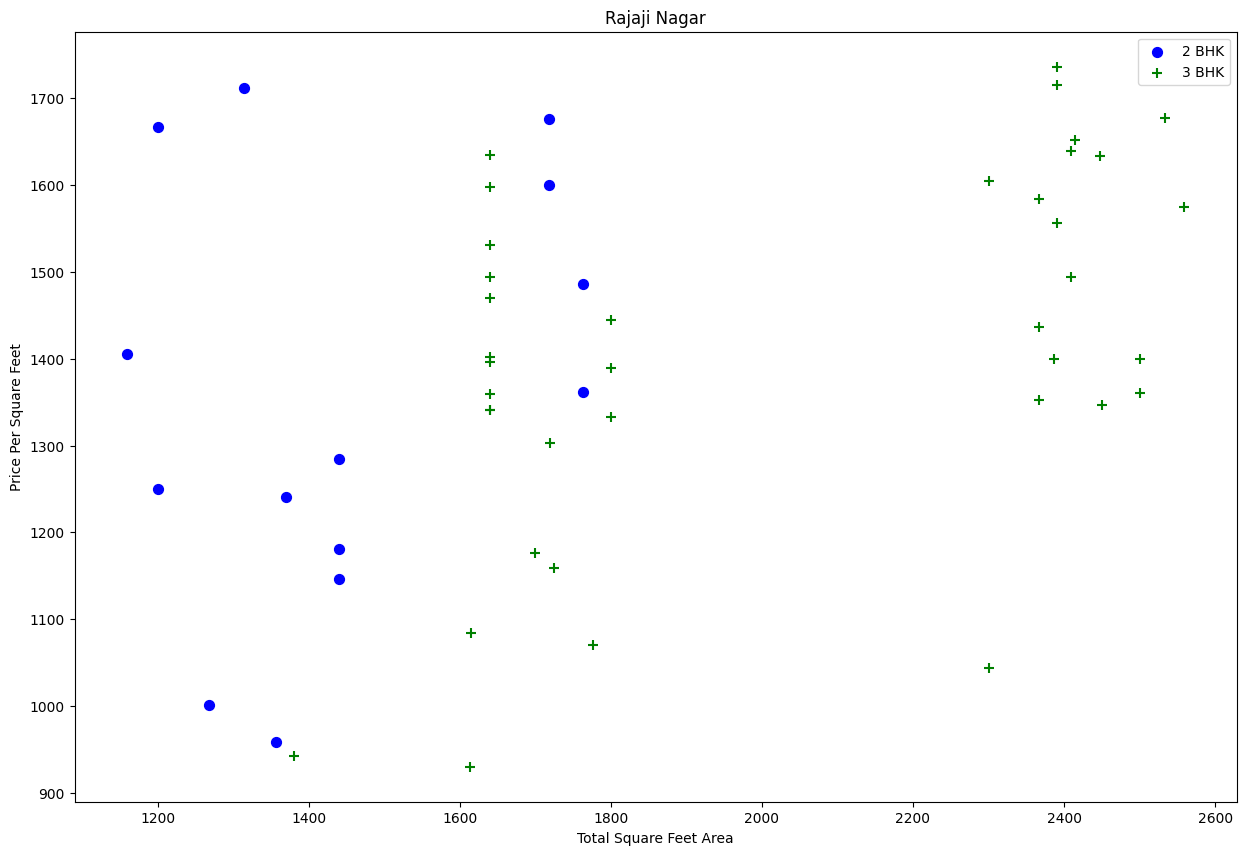

In [1266]:
import matplotlib.pyplot as plt

def plot_scatter_chart(data6, location):
    bhk2 = data6[(data6.location == location) & (data6.new_size == 2)]
    bhk3 = data6[(data6.location == location) & (data6.new_size == 3)]
    plt.figure(figsize=(15, 10))
    plt.scatter(
        bhk2.total_sqft,
        bhk2.converted_price,
        color='blue',
        label='2 BHK',
        s=50 )
    plt.scatter(
        bhk3.total_sqft,
        bhk3.converted_price,
        marker='+',
        color='green',
        label='3 BHK',
        s=50
    )

    plt.xlabel("Total Square Feet Area")
    plt.ylabel("Price Per Square Feet")
    plt.title(location)
    plt.legend()
    plt.show()

plot_scatter_chart(data6, "Rajaji Nagar")

In [1267]:
len(data6['location'].unique())

242

In [1268]:
# remove the 2 seated bedrooms whose prices are less than 1 seated bedrooms 
def remove_bhk_outliers(df):
    exclude_indices = np.array([])
    for location, location_df in df.groupby('location'):
        bhk_stats = {}
        for bhk, bhk_df in location_df.groupby('new_size'):
            bhk_stats[bhk] = {
                'mean': np.mean(bhk_df.converted_price),
                'std': np.std(bhk_df.converted_price),
                'count': bhk_df.shape[0]
            }
        for bhk, bhk_df in location_df.groupby('new_size'):
            stats = bhk_stats.get(bhk - 1)
            if stats and stats['count'] > 5:
                exclude_indices = np.append(
                    exclude_indices,
                    bhk_df[bhk_df.converted_price < stats['mean']].index.values
                )

    return df.drop(exclude_indices, axis='index')

data7 = remove_bhk_outliers(data6)

data7.shape

(7329, 7)

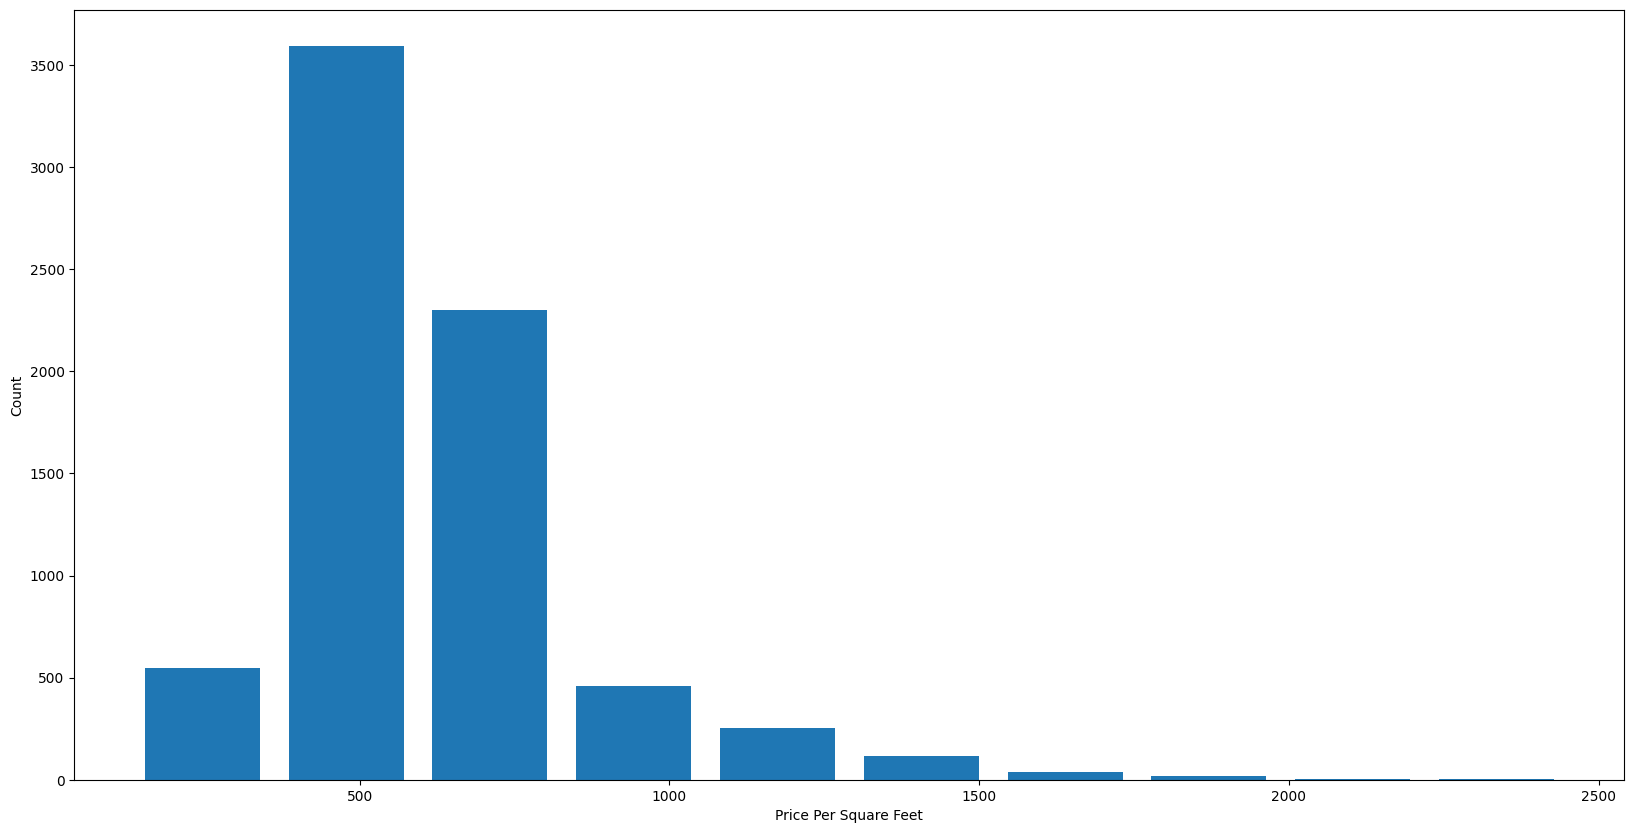

In [1269]:
plt.rcParams["figure.figsize"] = (20, 10)
plt.hist(data7.converted_price, rwidth=0.8)
plt.xlabel("Price Per Square Feet")
plt.ylabel("Count")
plt.show()


Text(0, 0.5, 'Count')

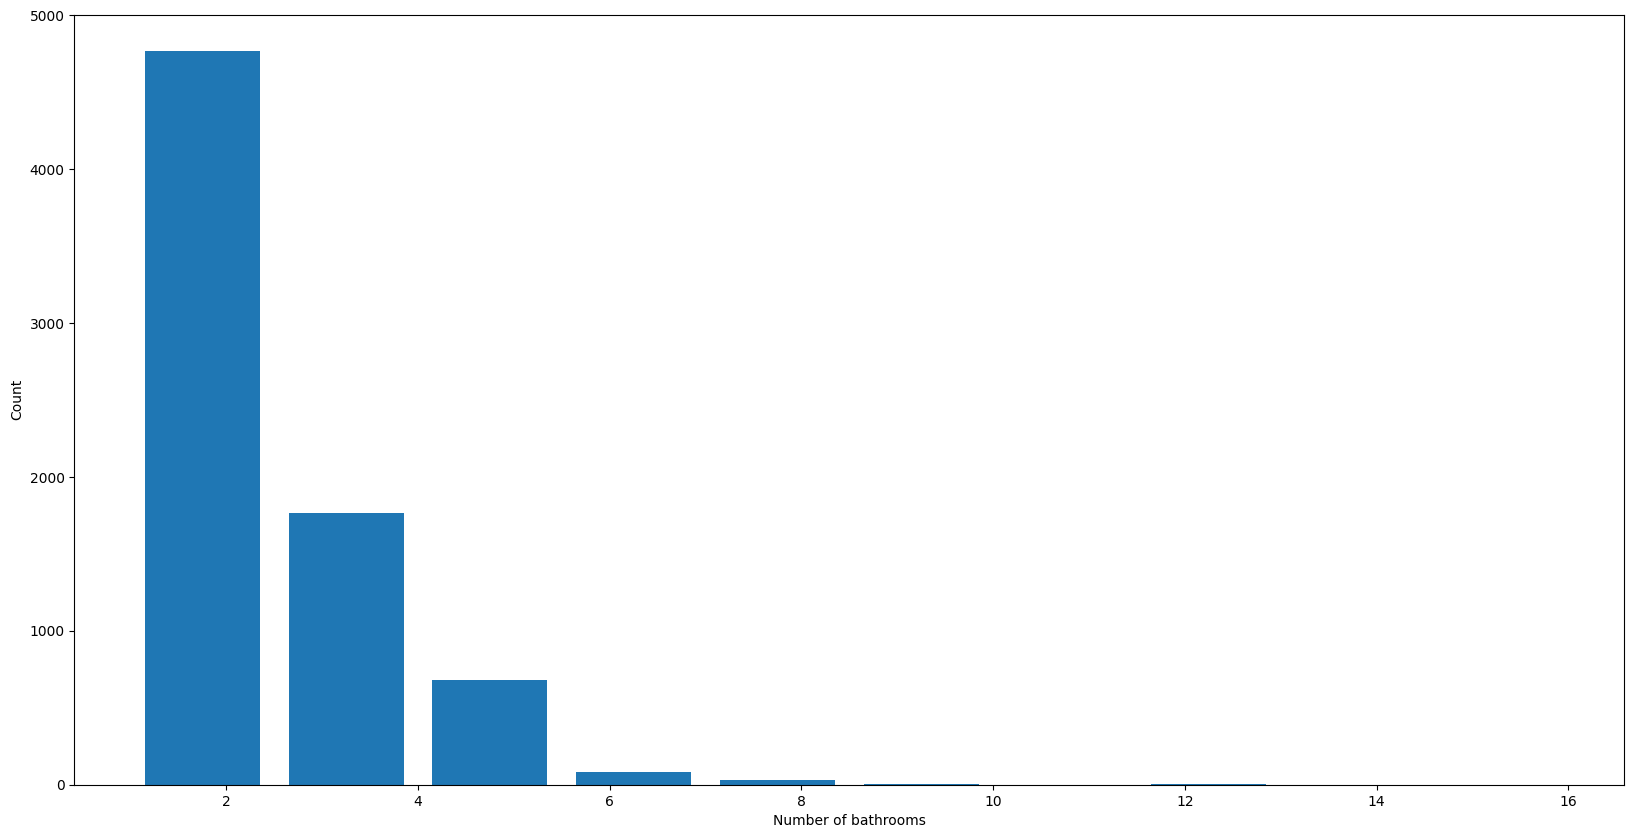

In [1270]:
plt.hist(data7['bath'], rwidth=0.8)
plt.xlabel("Number of bathrooms")
plt.ylabel("Count")

In [1271]:
data7[data7['bath']>data7['new_size']+2]
data7.shape

(7329, 7)

In [1272]:
data8 = data7[(data7['bath']<data7['new_size']+2)]
data8.shape

(7251, 7)

In [1273]:
data8.head()

,location,size,total_sqft,bath,price,new_size,converted_price
0,1st Block Jayanagar,4 BHK,2850.0,4.0,428.0,4,1501.754386
1,1st Block Jayanagar,3 BHK,1630.0,3.0,194.0,3,1190.184049
2,1st Block Jayanagar,3 BHK,1875.0,2.0,235.0,3,1253.333333
3,1st Block Jayanagar,3 BHK,1200.0,2.0,130.0,3,1083.333333
4,1st Block Jayanagar,2 BHK,1235.0,2.0,148.0,2,1198.380567


In [1274]:
data9 =data8.copy()
data9 = data8.drop(columns=["size", "converted_price"])

In [1275]:
len(data9['location'].unique())

242

In [1276]:
len(data9['location'].unique())
dummies = pd.get_dummies(data9['location'])
dummies.head()

,1st Block Jayanagar,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,5th Block Hbr Layout,5th Phase JP Nagar,6th Phase JP Nagar,7th Phase JP Nagar,8th Phase JP Nagar,9th Phase JP Nagar,...,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur,others
0,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [1277]:
data9.head()

,location,total_sqft,bath,price,new_size
0,1st Block Jayanagar,2850.0,4.0,428.0,4
1,1st Block Jayanagar,1630.0,3.0,194.0,3
2,1st Block Jayanagar,1875.0,2.0,235.0,3
3,1st Block Jayanagar,1200.0,2.0,130.0,3
4,1st Block Jayanagar,1235.0,2.0,148.0,2


In [1278]:
data10 = pd.concat([data9, dummies.drop('others', axis='columns')], axis='columns')

In [1279]:
data10.head()

,location,total_sqft,bath,price,new_size,1st Block Jayanagar,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,5th Block Hbr Layout,...,Vijayanagar,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur
0,1st Block Jayanagar,2850.0,4.0,428.0,4,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1st Block Jayanagar,1630.0,3.0,194.0,3,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1st Block Jayanagar,1875.0,2.0,235.0,3,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1st Block Jayanagar,1200.0,2.0,130.0,3,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1st Block Jayanagar,1235.0,2.0,148.0,2,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [1280]:
data10 = data10.drop(columns=['location'], axis='columns')
data10.head()

,total_sqft,bath,price,new_size,1st Block Jayanagar,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,5th Block Hbr Layout,5th Phase JP Nagar,...,Vijayanagar,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur
0,2850.0,4.0,428.0,4,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1630.0,3.0,194.0,3,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1875.0,2.0,235.0,3,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1200.0,2.0,130.0,3,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1235.0,2.0,148.0,2,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [1281]:
X = data10.drop("price", axis="columns")
y = data10['price']

In [1282]:
y.head()

0    428.0
1    194.0
2    235.0
3    130.0
4    148.0
Name: price, dtype: float64

In [1283]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=10)


In [1284]:
from sklearn.linear_model import LinearRegression
linearmodel = LinearRegression()
linearmodel.fit(X_train, y_train)
linearmodel.score(X_test,y_test)

0.8452277697874319

In [1285]:
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import cross_val_score

cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0)

cross_val_score(LinearRegression(), X,y, cv=cv)

array([0.82430186, 0.77166234, 0.85089567, 0.80837764, 0.83653286])

In [1286]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Lasso, LinearRegression
from sklearn.tree import DecisionTreeRegressor
import pandas as pd

def best_model_searchcv(X, y):
    algos = {
        "linearregression": {
            "model": LinearRegression(),
            "params": {
                "fit_intercept": [True, False]
            }
        },
        "lasso": {
            "model": Lasso(),
            "params": {
                "alpha": [1, 2],
                "selection": ['random', 'cyclic']
            }
        },
        "decision_tree": {
            "model": DecisionTreeRegressor(),
            "params": {
                "criterion": ['squared_error', 'friedman_mse'],
                "splitter": ['best', 'random']
            }
        }
    }

    score = []
    cv = ShuffleSplit(n_splits=5, test_size=0.2 ,random_state=0)
    for algo_name, config in algos.items():
        gs = GridSearchCV(config['model'], config['params'], cv=cv, return_train_score=False)
        gs.fit(X,y)
        score.append({"model": algo_name,"best_score":gs.best_score_,"best_params":gs.best_params_ })
    return pd.DataFrame(score, columns=['model','best_score', 'best_params'])

best_model_searchcv(X,y)


,model,best_score,best_params
0,linearregression,0.819001,{'fit_intercept': False}
1,lasso,0.687444,"{'alpha': 1, 'selection': 'random'}"
2,decision_tree,0.720840,"{'criterion': 'friedman_mse', 'splitter': 'best'}"


In [ ]:
# def predicted_price(location, sqft, bath, bhk):
#     loc_index = np.where(X.columns==location)[0][0]

#     x = np.zeros(len(X.columns))
#     x[0] = sqft
#     x[1] = bath
#     x[2] = bhk
#     if loc_index >=0:
#         x[loc_index] = 1

#     return linearmodel.predict([x])[0]

In [1289]:
X.columns

Index(['total_sqft', 'bath', 'new_size', '1st Block Jayanagar',
       '1st Phase JP Nagar', '2nd Phase Judicial Layout',
       '2nd Stage Nagarbhavi', '5th Block Hbr Layout', '5th Phase JP Nagar',
       '6th Phase JP Nagar',
       ...
       'Vijayanagar', 'Vishveshwarya Layout', 'Vishwapriya Layout',
       'Vittasandra', 'Whitefield', 'Yelachenahalli', 'Yelahanka',
       'Yelahanka New Town', 'Yelenahalli', 'Yeshwanthpur'],
      dtype='object', length=244)

In [ ]:
# predicted_price('1st Block Jayanagar', 1000, 2, 2)

C:\Users\007\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


np.float64(201.99197906792244)

In [ ]:
# import pickle
# with open('housing_model.pkl', 'wb') as f: 
#     pickle.dump(linearmodel, f)

In [ ]:
# import json
# columns = {
#        "data_columns": [col.lower() for col in X.columns]
# }
# with open("columns.json", "w") as f:
#     f.write(json.dumps(columns))

True
0.3
